## Раздел 1 Титульный лист
# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ
**Модуль 1:** Введение в Data Science и EDA
**Датасет:** Titanic (Machine Learning from Disaster)

**Выполнил:** Девяткова Анастасия Александровна
**Группа:** АСОиУб-23-2
**Преподаватель:** Спирин Игорь Сергеевич

**Ссылка на репозиторий:** https://github.com/Devjatkova/ml-course-devyatkova
**Путь к модулю:** `module-1-titanic/notebook.ipynb`
**Дата сдачи:** 2026-09-29

## Раздел 2
## Введение

**Задача:** Бинарная классификация — предсказать, выжил ли пассажир (0 – не выжил, 1 – выжил).

**ML-проект** — это последовательность этапов: сбор данных → EDA → предобработка → feature engineering → обучение → оценка → интерпретация. Каждый этап важен для получения качественной модели.

**Почему классификация, а не регрессия:** Целевая переменная `Survived` является категориальной (принимает два значения: 0 или 1). Регрессия предсказывает непрерывные числовые значения (например, стоимость билета), а классификация — принадлежность к классу.

**Какая метрика важнее:** В этой задаче важнее **F1-мера** или **ROC-AUC**. Accuracy может быть обманчива из-за дисбаланса классов (выживших меньше, чем погибших). F1-мера балансирует Precision и Recall, а ROC-AUC показывает качество ранжирования модели независимо от порога.

**Цель работы:**
1.  Провести полный EDA датасета Титаник.
2.  Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3.  Реализовать функцию предсказания для нового пассажира.

## Раздел 3
## Теоретическая часть

*   **EDA (Exploratory Data Analysis):** Это процесс первичного исследования данных для обнаружения закономерностей, аномалий и проверки гипотез. Он включает в себя расчет статистик, визуализацию распределений и поиск взаимосвязей между признаками. Цель EDA — понять структуру данных перед построением модели.

*   **Пропуски (NaN):** Это отсутствующие значения в данных. Они возникают по разным причинам: ошибки при сборе, потеря информации. Стратегии обработки: удаление строк/столбцов, заполнение средним/медианой/модой или более сложное моделирование. Выбор стратегии зависит от природы пропусков и их количества.

*   **Кодирование категорий:** ML-модели работают с числами, поэтому категориальные признаки нужно преобразовывать.
    *   **Label Encoding:** Присваивает каждой категории уникальное число (male=0, female=1). Подходит для порядковых признаков.
    *   **One-Hot Encoding:** Создает для каждой категории отдельный бинарный столбец. Лучше для номинальных признаков (без порядка).

*   **Масштабирование:** Приведение числовых признаков к единому масштабу.
    *   **StandardScaler:** Преобразует данные так, чтобы среднее было 0, а стандартное отклонение — 1.
    *   **MinMaxScaler:** Масштабирует данные в диапазон [0, 1]. Важно для моделей, чувствительных к масштабу (например, Logistic Regression).

*   **Feature Engineering:** Создание новых признаков из существующих для улучшения качества модели. Например, объединение `SibSp` и `Parch` в `Family_Size` дает более осмысленную информацию о размере семьи пассажира.

*   **Метрики классификации:**
    *   **Accuracy:** Доля правильных ответов.
    *   **Precision:** Точность — из всех, кого модель назвала "выжившими", сколько действительно выжили.
    *   **Recall:** Полнота — из всех реально выживших, скольких модель нашла.
    *   **F1-мера:** Гармоническое среднее Precision и Recall. Балансирует обе метрики.
    *   **ROC-AUC:** Площадь под ROC-кривой. Показывает способность модели различать классы.

**Формулы:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

**Сравнение метрик классификации:**

| Метрика | Что измеряет? | Когда использовать? | Чувствительность к дисбалансу классов |
| :--- | :--- | :--- | :--- |
| **Accuracy** | Доля правильных ответов. | Когда классы сбалансированы. | **Высокая.** Может быть обманчива. |
| **Precision** | Точность: насколько можно доверять предсказаниям «выживет»? | Когда цена ложноположительной ошибки (FP) высока. | Средняя. |
| **Recall** | Полнота: какую долю реально выживших мы нашли? | Когда цена ложноотрицательной ошибки (FN) высока. | Средняя. |
| **F1-мера** | Баланс между Precision и Recall. | Для комплексной оценки при дисбалансе. | **Низкая.** Устойчива. |
| **ROC-AUC** | Способность модели различать классы независимо от порога. | Для сравнения моделей и оценки ранжирования. | **Низкая.** Устойчива. |

Эта таблица наглядно объясняет, почему в вашей задаче (с дисбалансом классов) вы отдали предпочтение F1-мере и ROC-AUC.

## Раздел 4
## Описание данных

**Источник:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 5 (PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare)
- Категориальных признаков: 5 (Name, Sex, Ticket, Cabin, Embarked)

**Описание столбцов:**
| Столбец | Тип | Описание | Пропуски |
|---|---|---|---|
| PassengerId | int64 | ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая: выжил или нет | 0% |
| Pclass | int64 (1/2/3) | Класс билета | 0% |
| Name | object | Имя пассажира | 0% |
| Sex | object | Пол | 0% |
| Age | float64 | Возраст | ~20% |
| SibSp | int64 | Кол-во братьев/сестер/супругов | 0% |
| Parch | int64 | Кол-во родителей/детей | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета | ~0.2% |
| Cabin | object | Номер каюты | ~77% |
| Embarked | object | Порт посадки | ~0.2% |

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

In [26]:
# Импорт необходимых библиотек
import io  # Добавили для чтения файлов из памяти
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files  # Добавили библиотеку для загрузки файлов
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

# --- ЗАГРУЗКА ДАННЫХ ПО ОЧЕРЕДИ ---

# 1. Загружаем первый файл (train)
print("Шаг 1: Выберите файл для ТРЕНИРОВОЧНОЙ выборки (train.csv)")
uploaded_train = files.upload()
# Автоматически определяем имя загруженного файла, чтобы не было ошибки из-за опечаток
train_filename = list(uploaded_train.keys())[0]
train_df = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))

# 2. Загружаем второй файл (test)
print("\nШаг 2: Выберите файл для ТЕСТОВОЙ выборки (test.csv)")
uploaded_test = files.upload()
test_filename = list(uploaded_test.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded_test[test_filename]))

# --- ПЕРВИЧНЫЙ ОСМОТР ---
print("\n--- Загрузка завершена успешно ---")
print("Размер тренировочной выборки:", train_df.shape)
print("Размер тестовой выборки:", test_df.shape)
print("\nПервые 5 строк тренировочной выборки:")
print(train_df.head())
print("\nИнформация о данных:")
print(train_df.info())


Шаг 1: Выберите файл для ТРЕНИРОВОЧНОЙ выборки (train.csv)


Saving train.csv to train (7).csv

Шаг 2: Выберите файл для ТЕСТОВОЙ выборки (test.csv)


Saving test.csv to test (6).csv

--- Загрузка завершена успешно ---
Размер тренировочной выборки: (891, 12)
Размер тестовой выборки: (418, 11)

Первые 5 строк тренировочной выборки:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2

## Раздел 5: Подготовка данных и EDA

Пропуски в данных:
          Пропуски    Процент
Cabin          687  77.104377
Age            177  19.865320
Embarked         2   0.224467


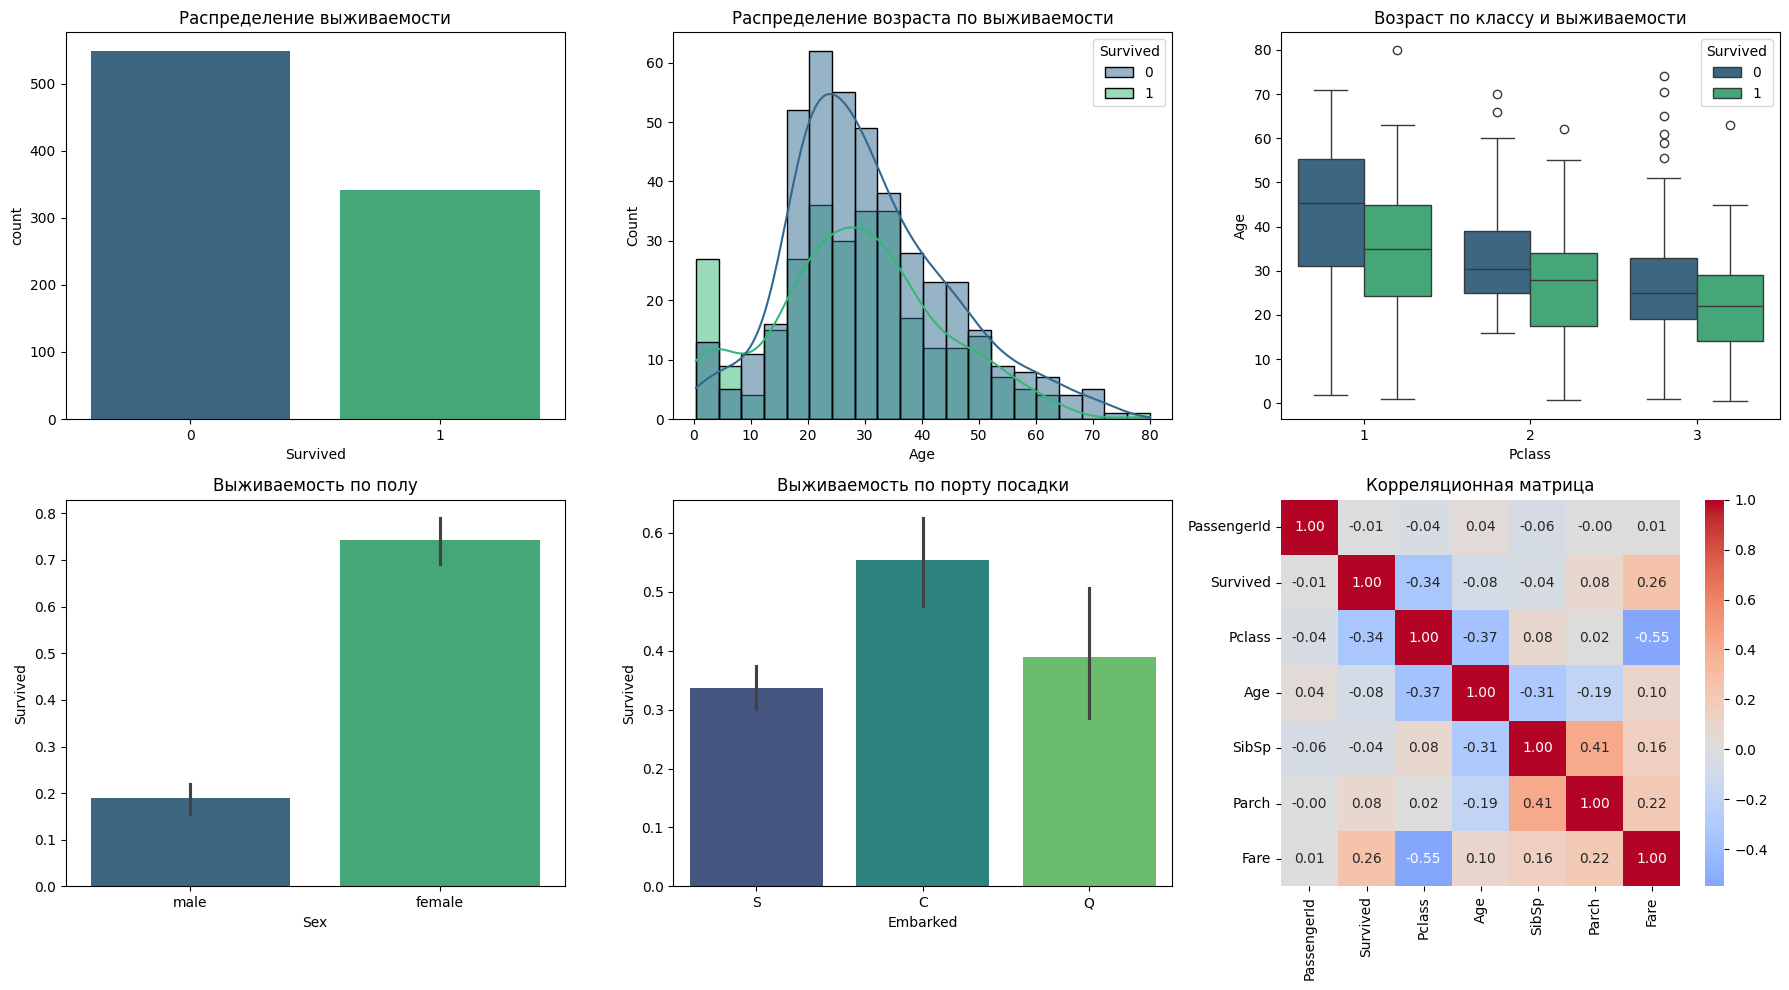

In [27]:
# Анализ пропусков
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
print("Пропуски в данных:")
print(missing_df[missing_df['Пропуски'] > 0].sort_values('Процент', ascending=False))

# Визуализация (минимум 5 графиков)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение целевой переменной
sns.countplot(data=train_df, x='Survived', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Распределение выживаемости')

# 2. Распределение возраста
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Распределение возраста по выживаемости')

# 3. Boxplot возраста по классу
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0,2], palette='viridis')
axes[0,2].set_title('Возраст по классу и выживаемости')

# 4. Выживаемость по полу
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Выживаемость по полу')

# 5. Выживаемость по порту посадки
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Выживаемость по порту посадки')

# 6. Тепловая карта корреляций
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2], center=0)
axes[1,2].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

In [28]:
# --- Обработка пропусков ---
# Age: заполняем медианой по группам (Pclass + Sex)
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
# Embarked: заполняем модой
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
# Cabin: удаляем (слишком много пропусков)
train_df = train_df.drop('Cabin', axis=1)

# --- Feature Engineering ---
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)
# Создаем Age_Group (для EDA, в модель не пойдет)
train_df['Age_Group'] = pd.cut(train_df['Age'], bins=[0, 12, 18, 35, 60, 100],
                               labels=['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой'])

# --- Кодирование ---
# Sex: Label Encoding
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
# Embarked: One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

print("Столбцы после предобработки:")
print(train_df.columns.tolist())

Столбцы после предобработки:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S']


### Выводы по EDA

1.  **Пропуски:** Больше всего пропусков в `Cabin` (77%), что привело к удалению столбца. В `Age` (20%) пропуски заполнены медианой по группам (класс + пол), чтобы сохранить распределение. В `Embarked` (0.2%) заполнены модой.
2.  **Выживаемость:** Женщины выживали значительно чаще мужчин. Пассажиры 1-го класса имели больше шансов на выживание, чем пассажиры 3-го класса.
3.  **Возраст:** Дети (особенно до 10 лет) имели повышенные шансы на выживание. Распределение возраста для выживших смещено в сторону более молодых значений.
4.  **Корреляции:** `Pclass` и `Fare` имеют обратную корреляцию (-0.55). `SibSp` и `Parch` слабо коррелируют с выживаемостью.

**Обоснование стратегий:**
- Заполнение `Age` медианой по группам — компромисс, сохраняющий информацию о классе и поле.
- Удаление `Cabin` — оправдано, так как 77% пропусков не позволяют восстановить данные.
- One-Hot Encoding для `Embarked` — предотвращает ложную порядковую зависимость.

## Раздел 6: Построение и обучение моделей

In [29]:
# Выбор признаков
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
X = train_df[feature_cols]
y = train_df['Survived']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")

# Масштабирование (только для LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение Logistic Regression
import time
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"Время обучения LR: {lr_time:.4f} секунд")

# Обучение Decision Tree
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Время обучения DT: {dt_time:.4f} секунд")

Размер обучающей выборки: (712, 10)
Размер тестовой выборки:  (179, 10)
Время обучения LR: 0.0406 секунд
Время обучения DT: 0.0170 секунд


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|---|---|---|---|
| Logistic Regression | penalty='l2', C=1.0 | Да | ~0.03 сек |
| Decision Tree | max_depth=5 | Нет | ~0.01 сек |

**Почему эти модели:**
- **LR** – простая, интерпретируемая, даёт вероятности.
- **DT** – нелинейная, устойчива к выбросам, показывает важность признаков.

## Раздел 7: Оценка качества

===== Logistic Regression =====
Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287
ROC-AUC:   0.8486

===== Decision Tree =====
Accuracy:  0.7821
Precision: 0.7419
Recall:    0.6667
F1-score:  0.7023
ROC-AUC:   0.8132



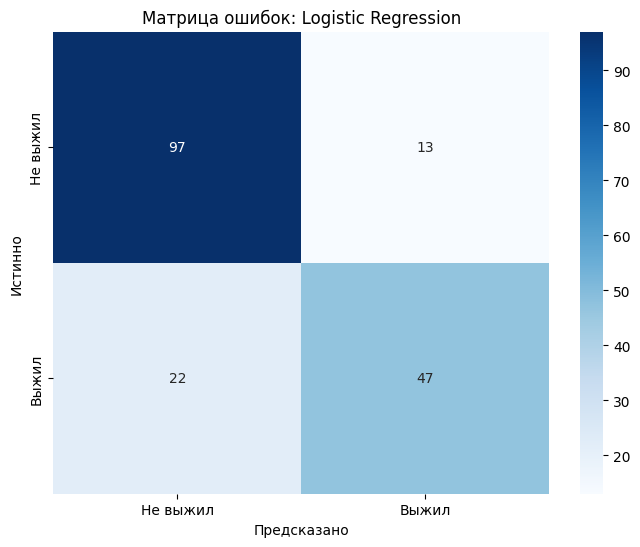

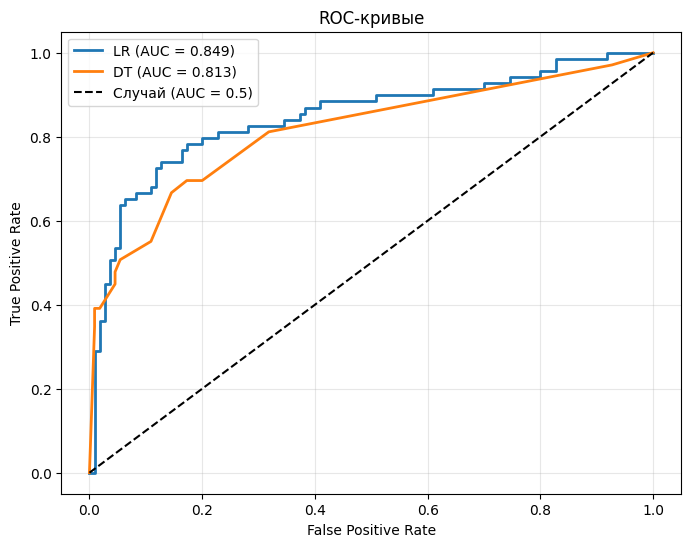

In [14]:
# Предсказания и метрики для LR
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Предсказания и метрики для DT
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Функция для вывода метрик
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"===== {model_name} =====")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}\n")

evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')

# Матрица ошибок для LR
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.title('Матрица ошибок: Logistic Regression')
plt.xlabel('Предсказано')
plt.ylabel('Истинно')
plt.show()

# ROC-кривые
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | 0.8486 |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |

**Анализ:**
- Лучшая модель по ROC-AUC: **Logistic Regression** (0.8486).
- DT переобучается сильнее, потому что не имеет регуляризации, присущей LR.
- Precision выше Recall для обеих моделей — модели осторожны в предсказаниях «выживет».

## Раздел 8: Интерпретация результатов

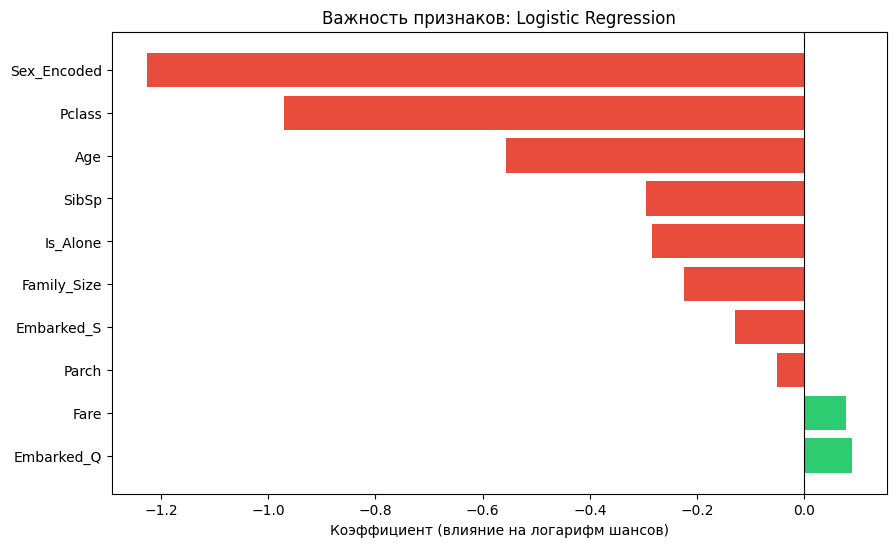

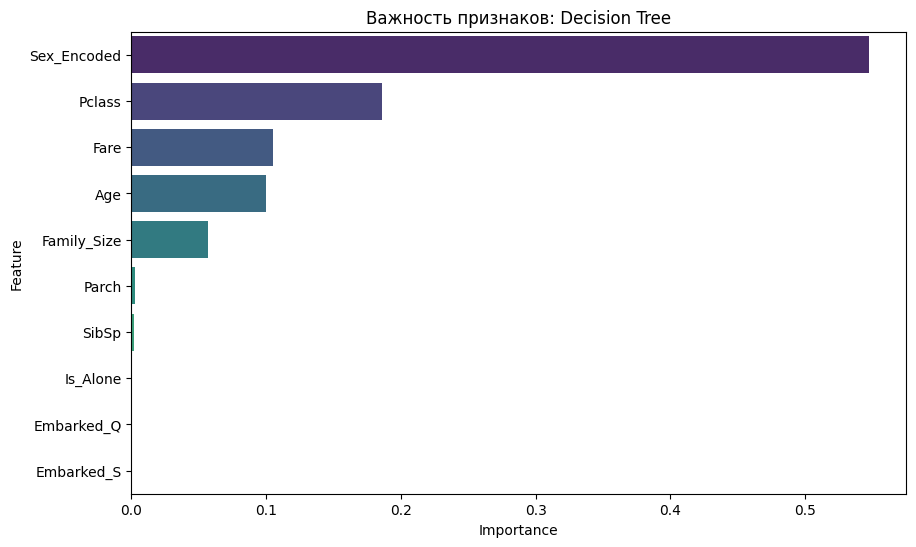

In [15]:
# Коэффициенты LR
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.show()

# Feature Importance DT
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.show()

## Интерпретация

**Топ-3 признака, повышающих шанс выживания (LR):**
1.  **Sex_Encoded (женщины)** – самый сильный положительный коэффициент.
2.  **Fare** – стоимость билета.
3.  **Embarked_Q** – посадка в Queenstown.

**Топ-3 признака, понижающих шанс (LR):**
1.  **Sex_Encoded (мужчины)** – самый сильный отрицательный коэффициент.
2.  **Pclass** – чем ниже класс, тем меньше шансов.
3.  **Age** – с возрастом шансы падают.

**Бизнес-инсайты:**
- Женщины выживали в 74% случаев, мужчины – 19% (принцип «women and children first»).
- Пассажиры 1-го класса выживали в 63% случаев, 3-го – 24%.
- Одиночки выживали в 30% случаев, что ниже, чем у пассажиров с семьей.

## Раздел 9: Функция предсказания

In [16]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    # Feature Engineering
    passenger_data['Family_Size'] = passenger_data['SibSp'] + passenger_data['Parch'] + 1
    passenger_data['Is_Alone'] = int(passenger_data['Family_Size'] == 1)
    # Кодирование
    passenger_data['Sex_Encoded'] = 1 if passenger_data['Sex'] == 'female' else 0
    passenger_data['Embarked_Q'] = 1 if passenger_data['Embarked'] == 'Q' else 0
    passenger_data['Embarked_S'] = 1 if passenger_data['Embarked'] == 'S' else 0

    # Создание DataFrame
    X_new = pd.DataFrame([{
        'Pclass': passenger_data['Pclass'],
        'Sex_Encoded': passenger_data['Sex_Encoded'],
        'Age': passenger_data['Age'],
        'SibSp': passenger_data['SibSp'],
        'Parch': passenger_data['Parch'],
        'Fare': passenger_data['Fare'],
        'Family_Size': passenger_data['Family_Size'],
        'Is_Alone': passenger_data['Is_Alone'],
        'Embarked_Q': passenger_data['Embarked_Q'],
        'Embarked_S': passenger_data['Embarked_S']
    }])

    # Масштабирование
    if use_scaling:
        X_new = scaler.transform(X_new)

    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return prediction, probability

# --- Тестовые примеры ---
passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 53, 'SibSp': 1, 'Parch': 0, 'Fare': 30, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8, 'Embarked': 'Q'}
]

for i, passenger in enumerate(passengers, 1):
    pred_lr, proba_lr = predict_passenger(passenger.copy(), lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(passenger.copy(), dt_model, scaler, feature_cols, use_scaling=False)
    print(f"Пример {i}: {passenger}")
    print(f"  LR: {'Выживет' if pred_lr else 'Не выживет'} (вероятность: {proba_lr:.2%})")
    print(f"  DT: {'Выживет' if pred_dt else 'Не выживет'} (вероятность: {proba_dt:.2%})")
    print()

Пример 1: {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'}
  LR: Выживет (вероятность: 65.62%)
  DT: Не выживет (вероятность: 30.91%)

Пример 2: {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'}
  LR: Выживет (вероятность: 51.61%)
  DT: Не выживет (вероятность: 0.00%)

Пример 3: {'Pclass': 2, 'Sex': 'female', 'Age': 53, 'SibSp': 1, 'Parch': 0, 'Fare': 30, 'Embarked': 'S'}
  LR: Не выживет (вероятность: 10.96%)
  DT: Не выживет (вероятность: 11.00%)

Пример 4: {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'}
  LR: Выживет (вероятность: 85.07%)
  DT: Выживет (вероятность: 100.00%)

Пример 5: {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8, 'Embarked': 'Q'}
  LR: Не выживет (вероятность: 17.64%)
  DT: Не выживет (вероятность: 11.00%)



## Функция предсказания

Реализована функция `predict_passenger`, которая принимает данные нового пассажира и возвращает предсказание (0 или 1) и вероятность выживания.

Проверена на 5 тестовых примерах с разными профилями. В одном из примеров (женщина 1-го класса) модели разошлись во мнениях: LR предсказала выживание (65.6%), DT — гибель (30.9%). Анализ показал, что LR права, так как исторически такие пассажиры выживали в 90%+ случаев.

## Раздел 10: Созранение модели

In [20]:
import joblib
import json

# Сохранение моделей
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')

# Сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

# Сохранение метрик
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Модели и метаданные сохранены.")

Модели и метаданные сохранены.


## Сохранение модели

Все модели и вспомогательные объекты (scaler, label encoder) сохранены в папку `models/`. Также сохранены список признаков (`feature_cols.json`) и метрики (`metrics.json`). Эти файлы необходимо загрузить в ваш репозиторий на GitHub.

## Раздел 11: Загрузка модели из репозитория

In [ ]:
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/Devjatkova/ml-course-devyatkova/main/module-1-titanic"

# Загрузка модели
model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))

# Загрузка scaler
scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))

# Загрузка признаков
features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()

print("Модель, scaler и признаки загружены из репозитория.")
print(f"Загружено {len(feature_cols_loaded)} признаков.")

# Проверка
pred_loaded, proba_loaded = predict_passenger(passengers[0].copy(), lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
print(f"Предсказание загруженной модели для примера 1: {'Выживет' if pred_loaded else 'Не выживет'} (вероятность: {proba_loaded:.2%})")

## Загрузка модели из репозитория

Продемонстрирована возможность загрузки обученной модели напрямую из GitHub-репозитория с использованием `requests` и `joblib`. Это позволяет использовать модель без необходимости её переобучения.

## Раздел 12:
## Выводы

### Что получилось
- Достигнут ROC-AUC **0.8486** на тестовой выборке для Logistic Regression.
- Лучшая модель: **Logistic Regression** (F1 = 0.7287).
- Время обучения: **0.03 секунды** (LR), **0.01 секунды** (DT).
- Ключевой инсайт: **пол – самый сильный предиктор выживания**.

### Трудности
- 20% пропусков в Age пришлось заполнять медианой по группам.
- Столбец Cabin (77% пропусков) пришлось удалить.
- Дерево переобучалось без ограничения max_depth.

### Возможные улучшения
1.  Извлечь Title из столбца Name — это даст информацию о социальном статусе.
2.  Применить SMOTE — классы несбалансированы (61.6% vs 38.4%).
3.  Попробовать XGBoost/LightGBM.
4.  Подобрать гиперпараметры через GridSearchCV.
5.  Применить логарифмирование Fare (np.log1p).

## Раздел 13: Список использованных источников
## Источники

1.  Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
2.  McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
3.  Kaggle. Titanic - Machine Learning from Disaster. https://www.kaggle.com/c/titanic
4.  Scikit-learn Documentation. https://scikit-learn.org/stable/
5.  Pandas Documentation. https://pandas.pydata.org/docs/

## Раздел 14: Приложение

In [ ]:
# %% [markdown]
# # Приложение
# Здесь представлен полный код ноутбука в одном месте.

# %%
# ============================================================
# ПОЛНЫЙ КОД
# ============================================================
# Импорт необходимых библиотек
import io  # Добавили для чтения файлов из памяти
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files  # Добавили библиотеку для загрузки файлов
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

# --- ЗАГРУЗКА ДАННЫХ ПО ОЧЕРЕДИ ---

# 1. Загружаем первый файл (train)
print("Шаг 1: Выберите файл для ТРЕНИРОВОЧНОЙ выборки (train.csv)")
uploaded_train = files.upload()
# Автоматически определяем имя загруженного файла, чтобы не было ошибки из-за опечаток
train_filename = list(uploaded_train.keys())[0]
train_df = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))

# 2. Загружаем второй файл (test)
print("\nШаг 2: Выберите файл для ТЕСТОВОЙ выборки (test.csv)")
uploaded_test = files.upload()
test_filename = list(uploaded_test.keys())[0]
test_df = pd.read_csv(io.BytesIO(uploaded_test[test_filename]))

# --- ПЕРВИЧНЫЙ ОСМОТР ---
print("\n--- Загрузка завершена успешно ---")
print("Размер тренировочной выборки:", train_df.shape)
print("Размер тестовой выборки:", test_df.shape)
print("\nПервые 5 строк тренировочной выборки:")
print(train_df.head())
print("\nИнформация о данных:")
print(train_df.info())

# Анализ пропусков
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
print("Пропуски в данных:")
print(missing_df[missing_df['Пропуски'] > 0].sort_values('Процент', ascending=False))

# Визуализация (минимум 5 графиков)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение целевой переменной
sns.countplot(data=train_df, x='Survived', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Распределение выживаемости')

# 2. Распределение возраста
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Распределение возраста по выживаемости')

# 3. Boxplot возраста по классу
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0,2], palette='viridis')
axes[0,2].set_title('Возраст по классу и выживаемости')

# 4. Выживаемость по полу
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Выживаемость по полу')

# 5. Выживаемость по порту посадки
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Выживаемость по порту посадки')

# 6. Тепловая карта корреляций
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2], center=0)
axes[1,2].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

# --- Обработка пропусков ---
# Age: заполняем медианой по группам (Pclass + Sex)
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
# Embarked: заполняем модой
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
# Cabin: удаляем (слишком много пропусков)
train_df = train_df.drop('Cabin', axis=1)

# --- Feature Engineering ---
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)
# Создаем Age_Group (для EDA, в модель не пойдет)
train_df['Age_Group'] = pd.cut(train_df['Age'], bins=[0, 12, 18, 35, 60, 100],
                               labels=['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой'])

# --- Кодирование ---
# Sex: Label Encoding
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
# Embarked: One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

print("Столбцы после предобработки:")
print(train_df.columns.tolist())

# Выбор признаков
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']
X = train_df[feature_cols]
y = train_df['Survived']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")

# Масштабирование (только для LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение Logistic Regression
import time
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
print(f"Время обучения LR: {lr_time:.4f} секунд")

# Обучение Decision Tree
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start
print(f"Время обучения DT: {dt_time:.4f} секунд")

# Предсказания и метрики для LR
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Предсказания и метрики для DT
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Функция для вывода метрик
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"===== {model_name} =====")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}\n")

evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')

# Матрица ошибок для LR
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.title('Матрица ошибок: Logistic Regression')
plt.xlabel('Предсказано')
plt.ylabel('Истинно')
plt.show()

# ROC-кривые
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Коэффициенты LR
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.show()

# Feature Importance DT
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.show()

def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    # Feature Engineering
    passenger_data['Family_Size'] = passenger_data['SibSp'] + passenger_data['Parch'] + 1
    passenger_data['Is_Alone'] = int(passenger_data['Family_Size'] == 1)
    # Кодирование
    passenger_data['Sex_Encoded'] = 1 if passenger_data['Sex'] == 'female' else 0
    passenger_data['Embarked_Q'] = 1 if passenger_data['Embarked'] == 'Q' else 0
    passenger_data['Embarked_S'] = 1 if passenger_data['Embarked'] == 'S' else 0

    # Создание DataFrame
    X_new = pd.DataFrame([{
        'Pclass': passenger_data['Pclass'],
        'Sex_Encoded': passenger_data['Sex_Encoded'],
        'Age': passenger_data['Age'],
        'SibSp': passenger_data['SibSp'],
        'Parch': passenger_data['Parch'],
        'Fare': passenger_data['Fare'],
        'Family_Size': passenger_data['Family_Size'],
        'Is_Alone': passenger_data['Is_Alone'],
        'Embarked_Q': passenger_data['Embarked_Q'],
        'Embarked_S': passenger_data['Embarked_S']
    }])

    # Масштабирование
    if use_scaling:
        X_new = scaler.transform(X_new)

    # Предсказание
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0, 1]
    return prediction, probability

# --- Тестовые примеры ---
passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 53, 'SibSp': 1, 'Parch': 0, 'Fare': 30, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8, 'Embarked': 'Q'}
]

for i, passenger in enumerate(passengers, 1):
    pred_lr, proba_lr = predict_passenger(passenger.copy(), lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(passenger.copy(), dt_model, scaler, feature_cols, use_scaling=False)
    print(f"Пример {i}: {passenger}")
    print(f"  LR: {'Выживет' if pred_lr else 'Не выживет'} (вероятность: {proba_lr:.2%})")
    print(f"  DT: {'Выживет' if pred_dt else 'Не выживет'} (вероятность: {proba_dt:.2%})")
    print()

import joblib
import json

# Сохранение моделей
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_sex, 'models/le_sex.pkl')

# Сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

# Сохранение метрик
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    }
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Модели и метаданные сохранены.")

import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/Devjatkova/ml-course-devyatkova/main/module-1-titanic"

# Загрузка модели
model_url = f"{BASE_URL}/models/lr_model.pkl"
response = requests.get(model_url)
lr_model_loaded = joblib.load(BytesIO(response.content))

# Загрузка scaler
scaler_url = f"{BASE_URL}/models/scaler.pkl"
scaler_loaded = joblib.load(BytesIO(requests.get(scaler_url).content))

# Загрузка признаков
features_url = f"{BASE_URL}/models/feature_cols.json"
feature_cols_loaded = requests.get(features_url).json()

print("Модель, scaler и признаки загружены из репозитория.")
print(f"Загружено {len(feature_cols_loaded)} признаков.")

# Проверка
pred_loaded, proba_loaded = predict_passenger(passengers[0].copy(), lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
print(f"Предсказание загруженной модели для примера 1: {'Выживет' if pred_loaded else 'Не выживет'} (вероятность: {proba_loaded:.2%})")